
STEP 41: Loading dataset
Dataset loaded
Shape: (300, 33)

STEP 42: Loading best model
Gradient Boosting model loaded

STEP 43: Extracting feature importance

Top 15 Most Important Features:

                                      feature  importance
7                              QoA_resolution    0.695732
11                             QoA_audio-rate    0.158100
8                                 QoA-bitrate    0.052174
0                               QoS_bandwidth    0.020492
18                          QoD-cpu_bigo-mips    0.014661
1                                   QoS_delay    0.013021
10                             QoA_frame-drop    0.012572
2                                  QoS_jitter    0.009279
13                            QoD-cpu_mhz-moy    0.007156
9                              QoA-frame_rate    0.006275
14                            QoD-cpu_mhz-avg    0.003999
12                             QoA_audio-drop    0.002383
30  QoD_carte-class_VGA compatible controller    0.000

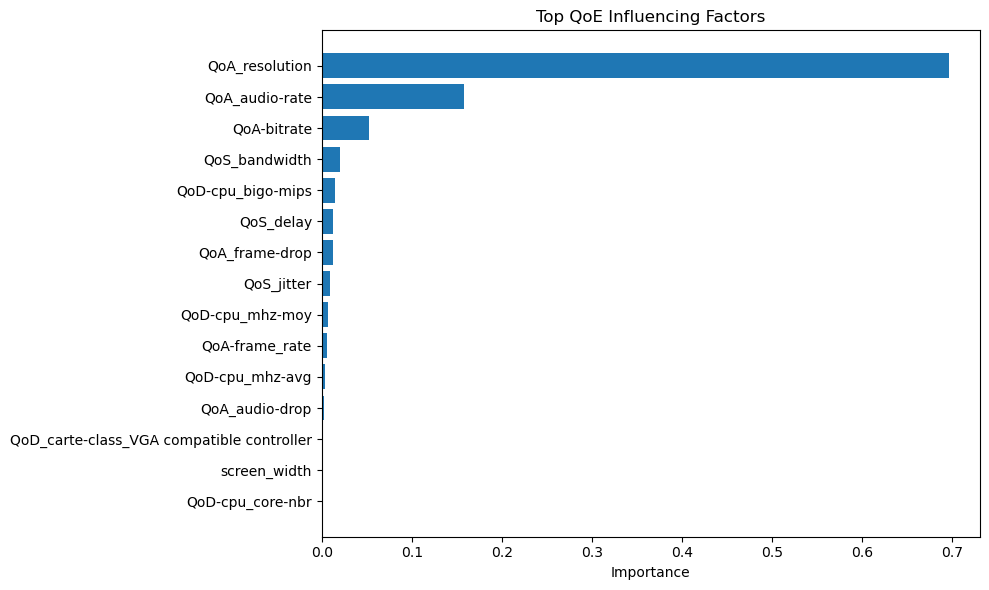


STEP 45: Saving feature importance
Feature importance saved to data/feature_importance.csv


In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

print("\n==============================")
print("STEP 41: Loading dataset")
print("==============================")

df = pd.read_csv("../data/engineered_dataset.csv")

df = df.drop(columns=["QoS_packet-loss"])

X = df.drop(columns=["MOS"])
y = df["MOS"]

print("Dataset loaded")
print("Shape:", df.shape)


print("\n==============================")
print("STEP 42: Loading best model")
print("==============================")

model = joblib.load("../models/best_gradient_boosting.pkl")

print("Gradient Boosting model loaded")


print("\n==============================")
print("STEP 43: Extracting feature importance")
print("==============================")

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print("\nTop 15 Most Important Features:\n")

print(feature_importance.head(15))


print("\n==============================")
print("STEP 44: Plotting feature importance")
print("==============================")

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["feature"][:15][::-1],
    feature_importance["importance"][:15][::-1]
)

plt.xlabel("Importance")

plt.title("Top QoE Influencing Factors")

plt.tight_layout()

plt.show()


print("\n==============================")
print("STEP 45: Saving feature importance")
print("==============================")

feature_importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)

print("Feature importance saved to data/feature_importance.csv")